# Ballon D'or Market: Kane vs. Dembele

-Test for mean reverting tendencies of Kalshi vs. Polyymarket probabilities to bookmaker adjusted proabilities following a major market event. 
-Do not trade during matches, check the reaction in first 0-2 hours then reversion over following 96 hours. 
-Key events:
    May 6 — Kane eliminated from UCL. Kane odds should drop, Dembele odds should rise simultaneously. 
    May 23 — Kane hat-trick in DFB-Pokal Final. Kane odds should recover.
    May 30 — UCL Final, Dembele goal and PSG title. Largest event. Dembele should surge. 

First get polymarket and Kalshi probabilities over time.

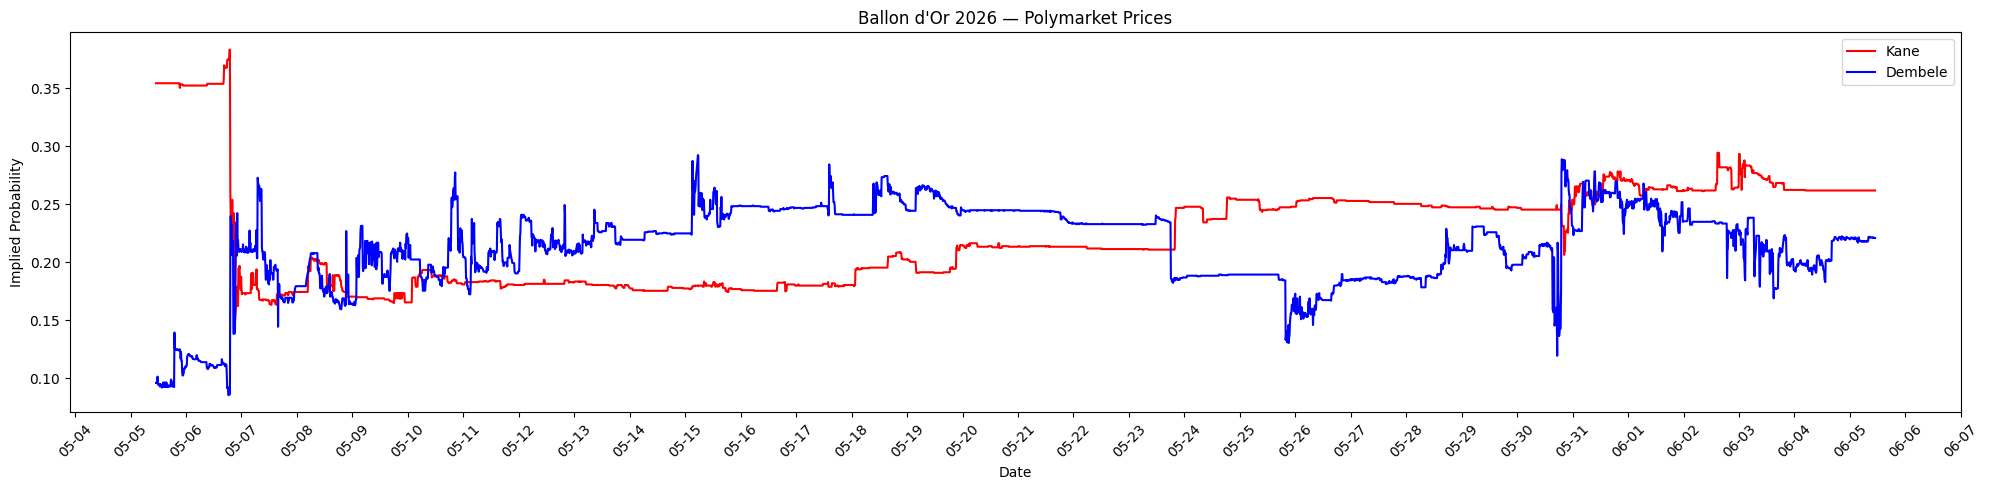

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# load both files
with open('../data/raw/ballon_dor/kane_10min_raw.json') as f:
    kane_raw = json.load(f)

with open('../data/raw/ballon_dor/dembele_10min_raw.json') as f:
    dem_raw = json.load(f)

# we convert our list of dictionaries into dataframes
# history is our key, and the time and price are the values
kane = pd.DataFrame(kane_raw['history'])
dem  = pd.DataFrame(dem_raw['history'])

# convert unix timestamps (which are seconds from 1st Jan 1970)
# use UTC timezone as this is polymarket standard
kane['date'] = pd.to_datetime(kane['t'], unit='s', utc=True)
dem['date']  = pd.to_datetime(dem['t'],  unit='s', utc=True)

# plot both on same chart
plt.figure(figsize=(20, 5))
plt.plot(kane['date'], kane['p'], label='Kane',    color='red')
plt.plot(dem['date'],  dem['p'],  label='Dembele', color='blue')

plt.xlabel('Date')
plt.ylabel('Implied Probability')
plt.title('Ballon d\'Or 2026 — Polymarket Prices')
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()